# Notebook 02 — Calidad, limpieza y preparación

**Objetivo:** Preparar el dataset a partir de decisiones justificadas con evidencia observada en la inspección inicial. Cada decisión indica la evidencia que la motivó, la acción aplicada y el impacto observado.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open('/content/streaming_users_dirty.json') as f:
    data = json.load(f)
df = pd.DataFrame(data)
print(f'Dataset cargado. Dimensiones iniciales: {df.shape}')

Dataset cargado. Dimensiones iniciales: (8160, 8)


## Paso 1 — Eliminación de filas duplicadas

In [2]:
# Evidencia: la inspección detectó 126 filas completamente duplicadas.
# Representan registros repetidos que distorsionarían cualquier agregación o análisis.
# Decisión: eliminar duplicados conservando la primera ocurrencia.
n_antes = len(df)
df = df.drop_duplicates()
print(f'Filas eliminadas: {n_antes - len(df)} | Filas restantes: {len(df)}')

Filas eliminadas: 126 | Filas restantes: 8034


## Paso 2 — Normalización de subscription_plan

In [3]:
# Evidencia: 15 variantes para 3 planes reales. Sin normalización, los análisis
# agrupados por plan producirían resultados fragmentados e incorrectos.
print('Antes:', df['subscription_plan'].value_counts().to_dict())

plan_map = {
    'Std': 'Estándar', 'estandar': 'Estándar', 'Estándar ': 'Estándar', 'STANDARD': 'Estándar',
    'basico': 'Básico', 'básico': 'Básico', 'BASICO': 'Básico', 'Basic': 'Básico',
    'premium': 'Premium', 'Premium ': 'Premium', 'Premiun': 'Premium', 'PREMIUM': 'Premium'
}
df['subscription_plan'] = df['subscription_plan'].replace(plan_map)
print('Después:', df['subscription_plan'].value_counts().to_dict())

Antes: {'Básico': 3395, 'Estándar': 2669, 'Premium': 1490, 'basico': 60, 'BASICO': 52, 'Basic': 52, 'básico': 50, 'Std': 48, 'Estándar ': 46, 'estandar': 36, 'STANDARD': 34, 'Premium ': 31, 'PREMIUM': 26, 'Premiun': 23, 'premium': 22}
Después: {'Básico': 3609, 'Estándar': 2833, 'Premium': 1592}


## Paso 3 — Normalización de country

In [4]:
# Evidencia: 26 variantes para 7 países. Mezcla de idiomas (Brazil/Brasil),
# capitalización (brasil/Brasil) y códigos ISO (BRA, MEX, ARG, COL, URY, PER, CHL).
country_map = {
    'Brazil': 'Brasil', 'brasil': 'Brasil', 'BRA': 'Brasil',
    'méxico': 'México', 'Mexico': 'México', 'MEX': 'México',
    'chile': 'Chile', 'Chile ': 'Chile', 'CHL': 'Chile',
    'ARG': 'Argentina', 'argentina': 'Argentina', 'Argentina ': 'Argentina',
    'COL': 'Colombia', 'colombia': 'Colombia',
    'URY': 'Uruguay', 'uruguay': 'Uruguay',
    'PER': 'Perú', 'Peru': 'Perú', 'perú': 'Perú'
}
df['country'] = df['country'].replace(country_map)
print('Países resultantes:', df['country'].unique())

Países resultantes: ['Brasil' 'Colombia' 'Uruguay' 'Perú' 'Chile' 'Argentina' 'México']


## Paso 4 — Normalización de favorite_genre

In [5]:
# Evidencia: 29 variantes para 7 géneros. Mezcla de idiomas (comedy/Comedia,
# Documentary/Documental, Action/Acción), capitalización y errores tipográficos (thriler).
genre_map = {
    'CRIME': 'Crime', 'Crimen': 'Crime', 'crime': 'Crime',
    'THRILLER': 'Thriller', 'thriler': 'Thriller', 'Thriller ': 'Thriller',
    'DRAMA': 'Drama', 'drama': 'Drama', 'Drama ': 'Drama',
    'ACCIÓN': 'Acción', 'accion': 'Acción', 'Action': 'Acción',
    'ROMANCE': 'Romance', 'romance': 'Romance', 'Romance ': 'Romance',
    'COMEDIA': 'Comedia', 'comedy': 'Comedia', 'Comedia ': 'Comedia',
    'Documental': 'Documental', 'Documentary': 'Documental',
    'DOC': 'Documental', 'documental': 'Documental'
}
df['favorite_genre'] = df['favorite_genre'].replace(genre_map)
print('Géneros resultantes:', df['favorite_genre'].dropna().unique())

Géneros resultantes: ['Crime' 'Thriller' 'Drama' 'Acción' 'Romance' 'Comedia' 'Documental']


## Paso 5 — Eliminación de outliers en age

In [6]:
# Evidencia: valores -5 (imposible), 130 y 150 (biológicamente inverosímiles).
# No pueden imputarse porque son errores de carga, no ausencias de información.
# Se considera rango válido: 13-100 años (edad mínima razonable para suscripción).
n = len(df)
print('Distribución de valores extremos en age:')
print(df[df['age'] < 13]['age'].value_counts())
print(df[df['age'] > 100]['age'].value_counts())
df = df[(df['age'] >= 13) & (df['age'] <= 100)]
print(f'Eliminados: {n - len(df)} | Restantes: {len(df)}')

Distribución de valores extremos en age:
age
 0    24
 4    22
-5    21
Name: count, dtype: int64
age
130    34
150    19
Name: count, dtype: int64
Eliminados: 120 | Restantes: 7914


## Paso 6 — Eliminación de outliers en monthly_watch_time_mins

In [7]:
# Evidencia: valores negativos (-120, -1) son físicamente imposibles para minutos de
# visualización. Valores 50000 y 99999 equivalen a 833+ horas mensuales, lo que supera
# las horas disponibles en un mes (720h), siendo errores de carga evidentes.
# Umbral máximo: 10000 minutos (~167 horas/mes, margen amplio pero razonable).
n = len(df)
df = df[(df['monthly_watch_time_mins'].isna()) |
        ((df['monthly_watch_time_mins'] >= 0) & (df['monthly_watch_time_mins'] <= 10000))]
print(f'Eliminados: {n - len(df)} | Restantes: {len(df)}')

Eliminados: 79 | Restantes: 7835


## Paso 7 — Eliminación de outliers en customer_support_tickets

In [8]:
# Evidencia: valor -1 es imposible (no puede haber tickets negativos).
# Valores 99 y 150 son inverosímiles para tickets mensuales de soporte de un
# usuario individual. Se establece umbral máximo de 50.
n = len(df)
df = df[(df['customer_support_tickets'] >= 0) & (df['customer_support_tickets'] <= 50)]
print(f'Eliminados: {n - len(df)} | Restantes: {len(df)}')

Eliminados: 94 | Restantes: 7741


## Paso 8 — Imputación de nulos en monthly_watch_time_mins

Nulos antes: 187
Mediana utilizada: 759.4 minutos


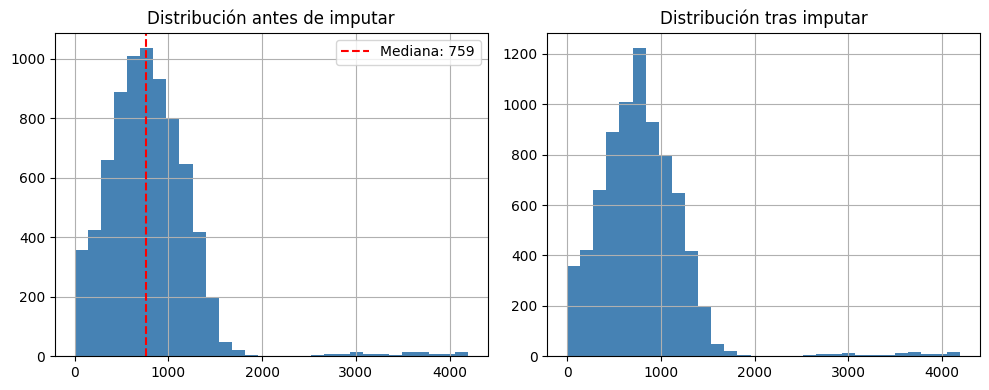

Nulos después: 0


In [9]:
# Evidencia: quedan nulos tras eliminar outliers. La distribución del tiempo de
# visualización es aproximadamente simétrica, por lo que la mediana es un estimador robusto.
mediana = df['monthly_watch_time_mins'].median()
print(f'Nulos antes: {df["monthly_watch_time_mins"].isnull().sum()}')
print(f'Mediana utilizada: {mediana:.1f} minutos')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['monthly_watch_time_mins'].dropna().hist(ax=axes[0], bins=30, color='steelblue')
axes[0].set_title('Distribución antes de imputar')
axes[0].axvline(mediana, color='red', linestyle='--', label=f'Mediana: {mediana:.0f}')
axes[0].legend()
df['monthly_watch_time_mins'] = df['monthly_watch_time_mins'].fillna(mediana)
df['monthly_watch_time_mins'].hist(ax=axes[1], bins=30, color='steelblue')
axes[1].set_title('Distribución tras imputar')
plt.tight_layout()
plt.show()
print(f'Nulos después: {df["monthly_watch_time_mins"].isnull().sum()}')

## Paso 9 — Imputación de nulos en favorite_genre

In [10]:
# Evidencia: variable categórica nominal sin orden natural. No es posible aplicar mediana.
# Se imputa con la moda (género más frecuente), que es la alternativa más conservadora
# para variables categóricas cuando los nulos no representan una categoría propia.
moda = df['favorite_genre'].mode()[0]
print(f'Nulos antes: {df["favorite_genre"].isnull().sum()}')
print(f'Moda utilizada: {moda}')
df['favorite_genre'] = df['favorite_genre'].fillna(moda)
print(f'Nulos después: {df["favorite_genre"].isnull().sum()}')

Nulos antes: 235
Moda utilizada: Comedia
Nulos después: 0


## Paso 10 — Corrección de last_login_date

In [11]:
# Evidencia: formatos mixtos (YYYY-MM-DD y YYYY/MM/DD) y fechas futuras imposibles.
# Acción 1: unificar formatos con pd.to_datetime(format='mixed').
# Acción 2: eliminar registros con fecha posterior a hoy (2025-06-27).
# Acción 3: imputar nulos restantes con la mediana de fechas válidas.
df['last_login_date'] = pd.to_datetime(df['last_login_date'], format='mixed', errors='coerce')
n = len(df)
df = df[df['last_login_date'] <= pd.Timestamp('2025-06-27')]
print(f'Registros con fecha futura eliminados: {n - len(df)}')
mediana_fecha = df['last_login_date'].median()
df['last_login_date'] = df['last_login_date'].fillna(mediana_fecha)
print(f'Nulos en fecha tras imputar: {df["last_login_date"].isnull().sum()}')

Registros con fecha futura eliminados: 901
Nulos en fecha tras imputar: 0


## Paso 11 — Verificación final y guardado

In [12]:
print('=== Estado final del dataset ===')
print(f'Dimensiones: {df.shape}')
print(f'Retención: {len(df)/8160*100:.1f}% de los registros originales')
print()
print('Nulos restantes:')
print(df.isnull().sum())
print()
df.describe()

=== Estado final del dataset ===
Dimensiones: (6840, 8)
Retención: 83.8% de los registros originales

Nulos restantes:
user_id                     0
age                         0
subscription_plan           0
monthly_watch_time_mins     0
country                     0
favorite_genre              0
last_login_date             0
customer_support_tickets    0
dtype: int64



,user_id,age,monthly_watch_time_mins,last_login_date,customer_support_tickets
count,6840.000000,6840.000000,6840.000000,6840,6840.000000
mean,13987.062573,33.638158,796.713377,2021-10-20 19:06:44.210526208,0.742251
min,10001.000000,13.000000,0.000000,2018-01-01 00:00:00,0.000000
25%,11966.750000,25.000000,499.750000,2019-11-24 18:00:00,0.000000
50%,13978.500000,33.000000,759.350000,2021-10-23 00:00:00,1.000000
75%,16013.250000,42.000000,1037.025000,2023-09-11 00:00:00,1.000000
max,17999.000000,80.000000,4193.700000,2025-06-27 00:00:00,5.000000
std,2320.520498,11.600098,494.777006,NaN,0.862247


In [14]:
df.to_csv('/content/streaming_users_clean.csv', index=False)
print('Dataset procesado guardado en data/processed/streaming_users_clean.csv')

Dataset procesado guardado en data/processed/streaming_users_clean.csv
